<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Market_Basket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 1: Import Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

PART 2: Load Dataset

In [17]:
data = pd.read_csv("Groceries_dataset.csv")

print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (38765, 3)
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


PART 3: Prepare Transactions

In [18]:
transactions = data.groupby("Member_number")["itemDescription"].apply(list).values.tolist()

print("\nExample transaction:", transactions[0])

# One-hot encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print("\nOne-hot encoded data shape:", df.shape)


Example transaction: ['soda', 'canned beer', 'sausage', 'sausage', 'whole milk', 'whole milk', 'pickled vegetables', 'misc. beverages', 'semi-finished bread', 'hygiene articles', 'yogurt', 'pastry', 'salty snack']

One-hot encoded data shape: (3898, 167)


PART 4: Frequent Itemsets (Apriori)

In [19]:
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

print("\nTop Frequent Itemsets:\n", frequent_itemsets.head(10))


Top Frequent Itemsets:
       support                        itemsets
85   0.458184                    (whole milk)
52   0.376603              (other vegetables)
64   0.349666                    (rolls/buns)
73   0.313494                          (soda)
86   0.282966                        (yogurt)
79   0.233710                (tropical fruit)
65   0.230631               (root vegetables)
6    0.213699                 (bottled water)
68   0.206003                       (sausage)
485  0.191380  (whole milk, other vegetables)


PART 5: Association Rules

In [20]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by="lift", ascending=False)

print("\nSample Rules:\n", rules.head(10))


Sample Rules:
                          antecedents                     consequents  \
2041           (whole milk, sausage)            (yogurt, rolls/buns)   
2036            (yogurt, rolls/buns)           (whole milk, sausage)   
2037            (yogurt, whole milk)           (rolls/buns, sausage)   
2040           (rolls/buns, sausage)            (yogurt, whole milk)   
1988      (yogurt, other vegetables)           (whole milk, sausage)   
1989           (whole milk, sausage)      (yogurt, other vegetables)   
2236         (yogurt, bottled water)  (whole milk, other vegetables)   
2237  (whole milk, other vegetables)         (yogurt, bottled water)   
2039        (rolls/buns, whole milk)               (yogurt, sausage)   
2038               (yogurt, sausage)        (rolls/buns, whole milk)   

      antecedent support  consequent support   support  confidence      lift  \
2041            0.106978            0.111339  0.022832    0.213429  1.916929   
2036            0.111339       

PART 6: Visualization - Frequent Itemsets

<Figure size 1000x500 with 0 Axes>

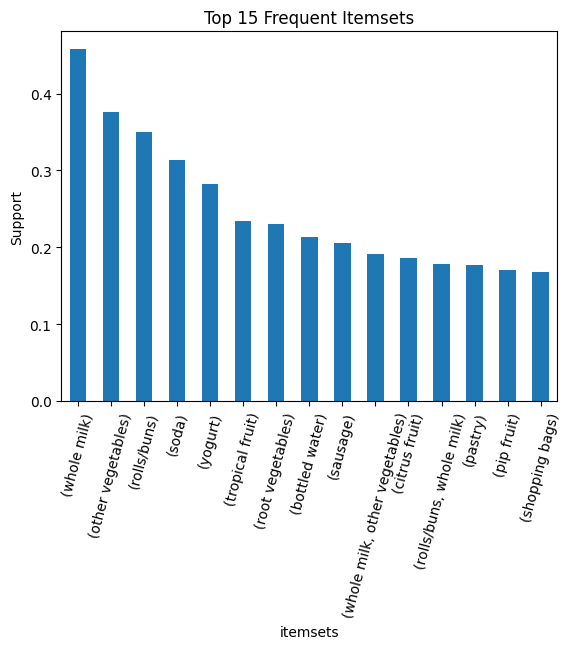

In [21]:
plt.figure(figsize=(10,5))
frequent_itemsets.head(15).plot(kind='bar', x='itemsets', y='support', legend=False)
plt.title("Top 15 Frequent Itemsets")
plt.ylabel("Support")
plt.xticks(rotation=75)
plt.show()

PART 7: Visualization - Association Rules Network

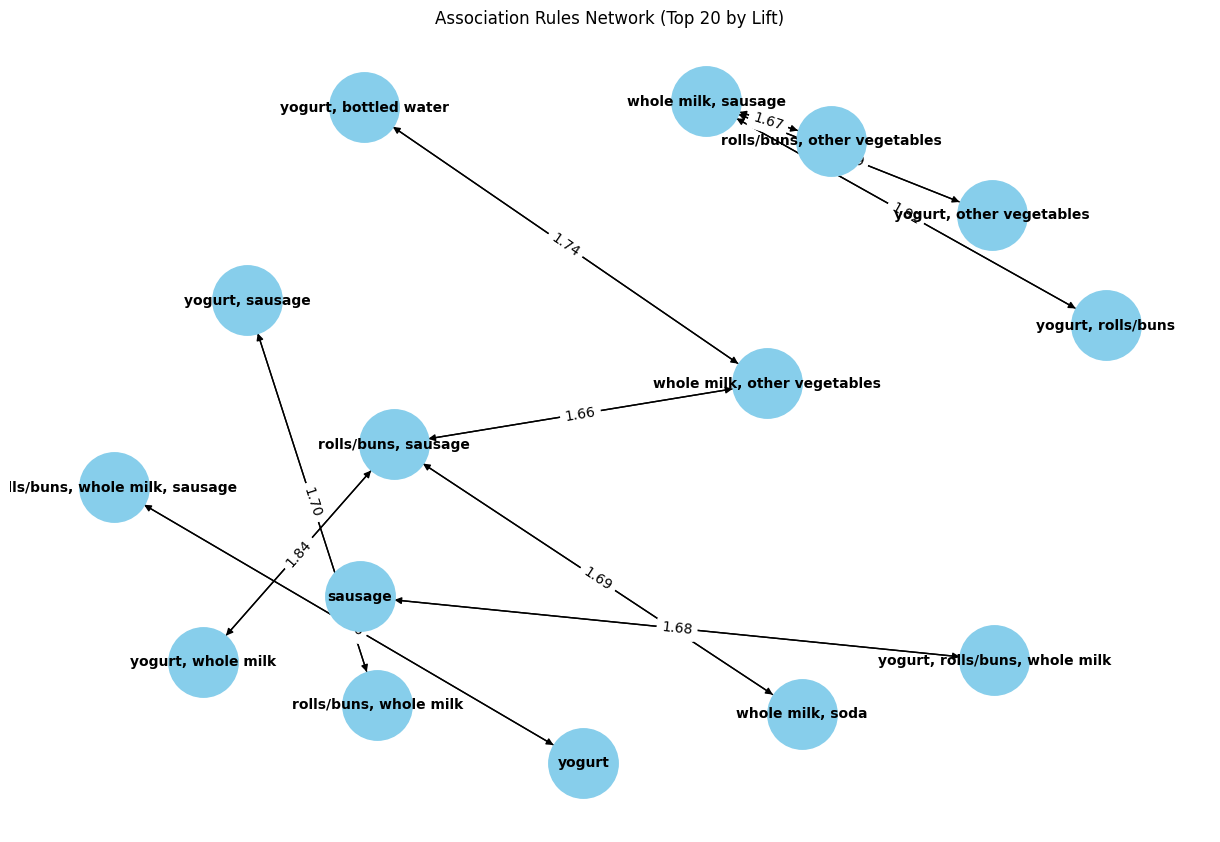

In [22]:
plt.figure(figsize=(12,8))
G = nx.DiGraph()

# Only plot top 20 rules
for _, row in rules.head(20).iterrows():
    G.add_edge(', '.join(list(row['antecedents'])),
               ', '.join(list(row['consequents'])),
               weight=row['lift'])

pos = nx.spring_layout(G, k=2, seed=42)
edges = G.edges(data=True)

nx.draw(G, pos, with_labels=True, node_size=2500, node_color="skyblue", font_size=10, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u,v): f"{d['weight']:.2f}" for u,v,d in edges})
plt.title("Association Rules Network (Top 20 by Lift)")
plt.show()